<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
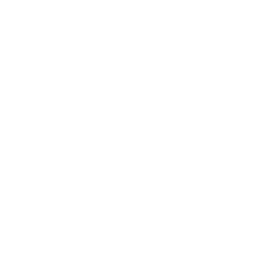
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Machined Part Dimension SPC with Phase Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Precision Manufacturing / Statistical Process Control &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A single CNC turning center produces a precision shaft whose outer
diameter (OD) is specified at **25.400 mm** with a known short-term
process standard deviation of **0.010 mm**. This notebook builds an
**Xbar-S control chart** with PROC SHEWHART over a 100-part production
run (20 rational subgroups of 5 parts) to detect a tool-wear drift.

Because the engineering target and short-term sigma are known
standards, the chart limits are fixed with `MU0=25.400` and
`SIGMA0=0.010` rather than estimated from the run itself — the standard
"known-standards" (Stage 2) SPC workflow. Western Electric sensitizing
rules (Tests 1-4) flag special-cause patterns. The analysis shows the
first ten subgroups in statistical control and a sustained upward shift
beginning at subgroup 11 that every subsequent subgroup signals.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.DIMENSION_DATA | Outer-diameter measurements, 5 parts per rational subgroup, 20 subgroups | 100 |

A controlled tool-wear shift of +0.025 mm (about 2.5 short-term sigma)
is injected at subgroup 11 to represent gradual flank wear on the
cutting insert.

---

In [1]:
/* --------------------------------------------------------
   Generate one CNC turning center's outer-diameter run.
   20 rational subgroups x 5 parts = 100 parts.
   Target OD 25.400 mm, short-term sigma 0.010 mm.
   A +0.025 mm tool-wear shift begins at subgroup 11.
   -------------------------------------------------------- */
data work.dimension_data;
    call streaminit(20260311);
    do subgroup_id = 1 to 20;
        if subgroup_id <= 10 then phase = 'Baseline ';
        else phase = 'PostShift';
        do sample = 1 to 5;
            if subgroup_id <= 10 then
                od_mm = round(rand('normal', 25.400, 0.010), 0.0001);
            else
                od_mm = round(rand('normal', 25.425, 0.010), 0.0001);
            output;
        end;
    end;
run;

NOTE: DATA work.dimension_data


NOTE: Wrote work.dimension_data (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Outer-diameter summary: baseline vs post-shift subgroups
   -------------------------------------------------------- */
proc means data=work.dimension_data n mean std min max maxdec=4;
    class phase;
    var od_mm;
    title 'Outer Diameter Summary: Baseline vs Post-Shift Subgroups';
run;

                                Outer Diameter Summary: Baseline vs Post-Shift Subgroups                                

                                                  The MEANS Procedure

                                               Analysis Variable : od_mm

        phase              N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------
        Baseline              50        25.3975         0.0113        25.3689        25.4247
        PostShift             50        25.4266         0.0104        25.4051        25.4551
        ------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                Outer Diameter Summary: Baseline vs Post-Shift Subgroups                                



NOTE: PROC SGPLOT data=work.dimension_data

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


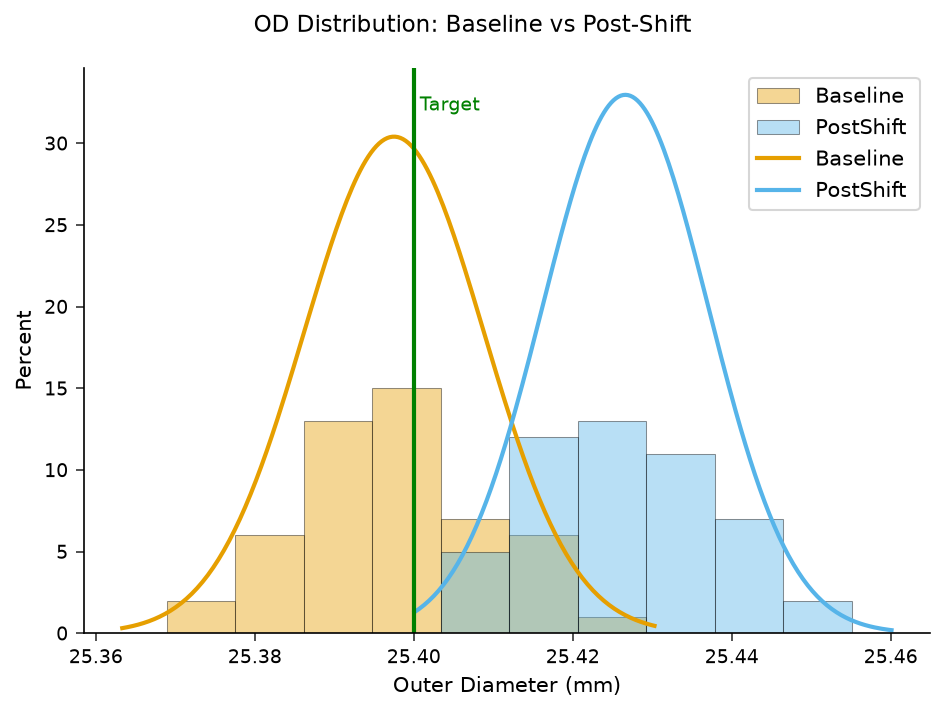

In [3]:
/* --------------------------------------------------------
   Distribution of OD before and after the shift
   -------------------------------------------------------- */
proc sgplot data=work.dimension_data;
    histogram od_mm / group=phase transparency=0.4;
    density od_mm / group=phase;
    refline 25.400 / axis=x lineattrs=(color=green thickness=2)
        label='Target';
    xaxis label='Outer Diameter (mm)';
    yaxis label='Percent';
    title 'OD Distribution: Baseline vs Post-Shift';
run;

---

                                Outer Diameter Summary: Baseline vs Post-Shift Subgroups                                


                    The SHEWHART Procedure
                    X-bar and s Chart (n=5) for od_mm

  Number of subgroups:    20
  Subgroup size (avg):    5.0
  Grand mean (X-bar-bar): 25.412060
  Average range (R-bar):  0.023260
  Center line:            25.400000
  Upper control limit:    25.413416
  Lower control limit:    25.386584
  Sigma:                  0.010000

  s Chart
  Center line:            0.009897
  Upper control limit:    0.020675
  Lower control limit:    0.000000

  Tests for Special Causes

  Test 1: One point more than 3 sigma from center line
    Violations at subgroups: 11, 12, 13, 14, 15, 16, 17, 18, 19, 20
  Test 2: 9 points in a row on same side of center line
    Violations at subgroups: 19, 20


  Phase variable: phase
  Phase values: Baseline , PostShift



NOTE: PROC SHEWHART
NOTE: PROC SHEWHART wrapper=python
NOTE: ODS plot written: shewhart_od_mm.spec.json
NOTE: Output table written to ./work/5d26fe1a-924f-4f11-a36d-17a28b069b98/chart_table.avro (20 observations)
NOTE: PROC SHEWHART statement used.


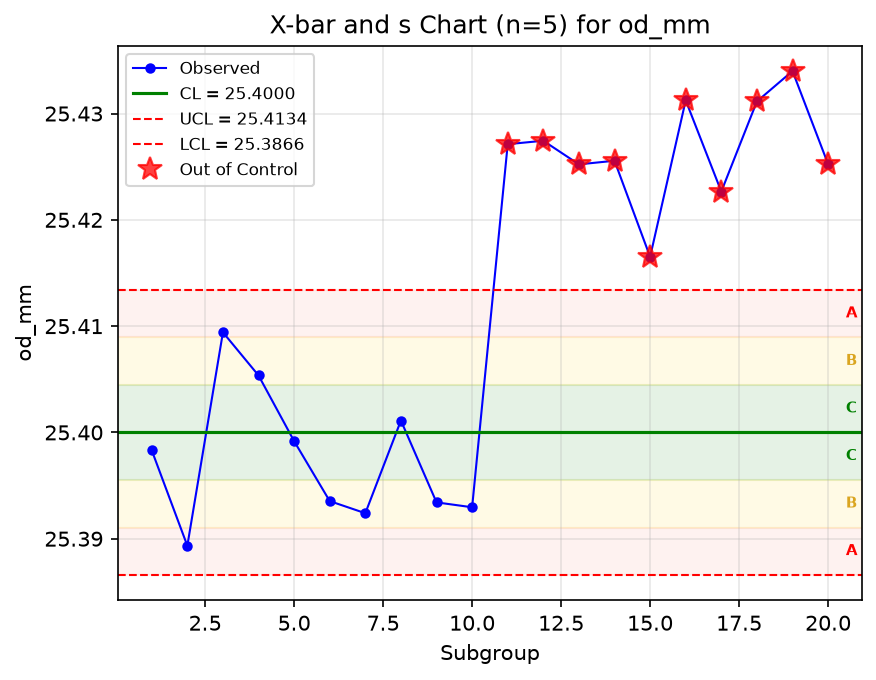

In [4]:
/* --------------------------------------------------------
   Xbar-S control chart against known standards.
   MU0 / SIGMA0 fix the limits at the engineering target and
   short-term sigma; Tests 1-4 apply Western Electric rules.
   OUTTABLE captures per-subgroup stats and the _EXLIM_ flag.
   -------------------------------------------------------- */
proc shewhart data=work.dimension_data;
    xschart od_mm * subgroup_id /
        subgroup = sample
        mu0      = 25.400
        sigma0   = 0.010
        tests    = 1 2 3 4
        outtable = work.chart_table
        xbarlab  = 'Mean OD (mm)'
        slab     = 'Within-subgroup Std Dev (mm)';
    title 'Xbar-S Control Chart for Machined OD (n=5, known standards)';
run;

---

In [5]:
/* --------------------------------------------------------
   Subgroups that breached the control limits
   _EXLIM_ = 'U' above the upper limit, 'L' below the lower
   -------------------------------------------------------- */
data work.ooc_signals;
    set work.chart_table;
    where _EXLIM_ ^= ' ';
    keep _SUBGRP_ _SUBX_ _MEAN_ _LCLX_ _UCLX_ _EXLIM_;
run;

proc print data=work.ooc_signals noobs;
    title 'Subgroups Beyond the Control Limits';
run;

                                          Subgroups Beyond the Control Limits                                           

_SUBGRP_    _SUBX_  _MEAN_     _LCLX_     _UCLX_  _EXLIM_
      11  25.42712    25.4  25.386584  25.413416  U
      12  25.42744    25.4  25.386584  25.413416  U
      13  25.42522    25.4  25.386584  25.413416  U
      14  25.42556    25.4  25.386584  25.413416  U
      15  25.41652    25.4  25.386584  25.413416  U
      16  25.43124    25.4  25.386584  25.413416  U
      17  25.42266    25.4  25.386584  25.413416  U
      18  25.43114    25.4  25.386584  25.413416  U
      19    25.434    25.4  25.386584  25.413416  U
      20  25.42524    25.4  25.386584  25.413416  U



NOTE: DATA work.ooc_signals


NOTE: Read 20 rows from work.chart_table.
NOTE: Wrote work.ooc_signals (10 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.ooc_signals

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


---

### Interpretation

Subgroups 1-10 represent stable baseline production: the PROC MEANS
summary reports a Baseline mean of **25.3975 mm** (std dev 0.0113 mm),
essentially on the 25.400 mm target. The PostShift subgroups average
**25.4266 mm** (std dev 0.0104 mm) — a roughly 0.029 mm rise in the
observed mean, consistent with the injected tool-wear drift.

Charting against the known standards (`MU0=25.400`, `SIGMA0=0.010`)
fixes the Xbar center line at 25.400 mm with limits at **25.3866 mm**
and **25.4134 mm**. Every baseline subgroup (1-10) plots in control.
Beginning at subgroup 11, every subgroup mean exceeds the upper control
limit: Test 1 (one point beyond 3 sigma) flags **subgroups 11 through
20**, and Test 2 (nine points in a row on one side of the center line)
flags **subgroups 19 and 20** once the post-shift run accumulates. The
out-of-control table lists all ten post-shift subgroups with `_EXLIM_`
= 'U'.

The signal is unambiguous and immediate: the chart catches the drift on
the first subgroup after it begins. Maintenance action — insert
replacement and offset re-zero — is warranted before the growing bias
consumes the upper specification margin.

---

In [6]:
/* --------------------------------------------------------
   Export the per-subgroup chart table and the out-of-control
   subgroups for manufacturing engineering review
   -------------------------------------------------------- */
proc export data=work.chart_table
    outfile='control_chart_table.csv'
    dbms=csv replace;
run;

proc export data=work.ooc_signals
    outfile='out_of_control_subgroups.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.chart_table outfile=control_chart_table.csv

NOTE: Exported 20 rows to control_chart_table.csv.
NOTE: PROC EXPORT data=work.ooc_signals outfile=out_of_control_subgroups.csv

NOTE: Exported 10 rows to out_of_control_subgroups.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>